# Conditional Poisson Sampling

$$
\newcommand{\w}{{\color{#2196F3}{w}}}
\newcommand{\bw}{{\color{#2196F3}{\boldsymbol{w}}}}
\newcommand{\W}{{\color{#2196F3}{W}}}
\newcommand{\Z}{{\color{#FF9800}{Z}}}
\newcommand{\pip}{{\color{#E91E63}{\pi}}}
\newcommand{\ba}{{\color{#2196F3}{\boldsymbol{a}}}}
\newcommand{\bb}{{\color{#2196F3}{\boldsymbol{b}}}}
\newcommand{\z}{{\color{#9C27B0}{z}}}
\newcommand{\llbracket}{[\![}
\newcommand{\rrbracket}{]\!]}
$$

<small><em>Color key: <span style="color:#2196F3">weights</span>, <span style="color:#E91E63">inclusion probabilities</span>, <span style="color:#FF9800">normalizing constant</span>, <span style="color:#9C27B0">formal variable</span>.</em></small>

<div style="float:right;max-width:200px;margin:0 0 0.5em 1em;padding:0.4em 0.6em;font-size:0.8em;color:#999;border-left:2px solid #ddd">
<a href="test_identities.py" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a> = numerically verified — each links to its test case in <a href="test_identities.py" style="color:#999">test_identities.py</a>.
</div>

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pylab as pl
from conditional_poisson import ConditionalPoisson

**Why fixed-size weighted subsets?**  Many problems require selecting exactly $n$ distinct items from a larger set, with selection probabilities controlled by item-level weights: survey sampling (draw $n$ households with probabilities proportional to size), stochastic beam search (maintain exactly $n$ hypotheses weighted by model scores), or subset selection in machine learning (choose $n$ features or data points for a diverse batch).  The hard part is doing this *exactly*—getting the right distribution, computing inclusion probabilities, and fitting weights—all efficiently.

Suppose you want to draw a random subset of exactly $n$ items from a universe $\mathcal{S}$ of $N$ items, where each item has a weight $\w_i \ge 0$ (collected into a vector $\bw \in [0, \infty]^N$) and the sample size $0 \le n \le N$ is fixed.  The probability of drawing a particular subset $S \in \tbinom{\mathcal{S}}{n}$ is proportional to the product of its weights:

$$
P(S) = \frac{\prod_{i \in S} \w_i}{\Z\tbinom{\bw}{n}}, \quad S \in \tbinom{\mathcal{S}}{n}
$$

where $\Z\tbinom{\bw}{n} = \sum_{S \in \tbinom{\mathcal{S}}{n}} \prod_{i \in S} \w_i$ is the normalizing constant <a href="test_identities.py#test_distribution_definition" title="test_distribution_definition, test_Z_is_elementary_symmetric_poly" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>—a weighted generalization of the binomial coefficient (when $\bw = \mathbf{1}$, we recover $\Z\tbinom{\bw}{n} = \binom{N}{n}$ — <a href="test_identities.py#test_Z_equals_binomial_when_uniform" title="test_Z_equals_binomial_when_uniform" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>).

**A small example.** Take $N = 4$ items with weights $\bw = (2, 3, 1, 5)$ and subset size $n = 2$.  There are $\binom{4}{2} = 6$ possible subsets:

| Subset $S$ | $\prod_{i \in S} \w_i$ | $P(S)$ |
|---|---|---|
| $\{1, 2\}$ | $2 \cdot 3 = 6$ | $6/41$ |
| $\{1, 3\}$ | $2 \cdot 1 = 2$ | $2/41$ |
| $\{1, 4\}$ | $2 \cdot 5 = 10$ | $10/41$ |
| $\{2, 3\}$ | $3 \cdot 1 = 3$ | $3/41$ |
| $\{2, 4\}$ | $3 \cdot 5 = 15$ | $15/41$ |
| $\{3, 4\}$ | $1 \cdot 5 = 5$ | $5/41$ |

The normalizing constant is $\Z\tbinom{\bw}{2} = 6+2+10+3+15+5 = 41$.  The inclusion probability of item 4 (with the largest weight, $\w_4 = 5$) is $\pip_4 = (10 + 15 + 5)/41 = 30/41 \approx 0.73$ — it appears in most subsets.  Item 3 ($\w_3 = 1$) has $\pip_3 = (2+3+5)/41 = 10/41 \approx 0.24$.  We'll use this running example to trace the product tree algorithm below.

This is the **conditional Poisson distribution**.  The name comes from its construction: in *Poisson sampling*, each item $i$ is included independently with probability $p_i$—but the sample size is random.  *Conditioning* on the sample size being exactly $n$ gives the conditional Poisson distribution.  Concretely, set $p_i = \w_i/(1+\w_i)$, so the weight $\w_i$ is the *odds* of the $i$-th coin flip: $\w_i = p_i / (1 - p_i)$. <a href="test_identities.py#test_weight_is_odds" title="test_weight_is_odds, test_conditional_poisson_from_bernoulli" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>

Among all distributions over size-$n$ subsets with given marginal inclusion probabilities $\pip_i = P(i \in S)$, the conditional Poisson distribution is the unique **maximum-entropy** one <a href="test_identities.py#test_max_entropy" title="test_max_entropy" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>—it makes the fewest assumptions beyond the marginals ([maximum-entropy](https://en.wikipedia.org/wiki/Principle_of_maximum_entropy); [Jaynes, 1957](https://doi.org/10.1103/PhysRev.106.620); [Chen, Dempster & Liu, 1994](https://academic.oup.com/biomet/article-abstract/81/3/457/256956)).  This is the same sense in which the Gaussian is the max-entropy distribution with given mean and variance.  Intuitively, CPS spreads probability as uniformly as possible across all size-$n$ subsets, subject to the constraint that each item's marginal inclusion rate matches $\pip_i$.

In this post, I'll describe an implementation that computes inclusion probabilities, draws exact samples, and fits weights to target probabilities—all in $O(N \log^2 n)$ time using a polynomial product tree with FFT-based multiplication and a contour-scaling trick for numerical stability.  The code is available as a Python library: [`conditional_poisson.py`](https://github.com/timvieira/conditional-poisson-sampling/blob/main/conditional_poisson.py) (NumPy) and [`torch_fft_prototype.py`](https://github.com/timvieira/conditional-poisson-sampling/blob/main/torch_fft_prototype.py) (PyTorch, with autograd support).

**Outline:**
1. Two simple rejection samplers — correct but impractical — to motivate the need for better machinery
2. The polynomial product tree: upward pass ($\Z$), downward pass ($\pip$), and sampling, with the $N\!=\!4$ example at each step
3. Library API and demos
4. Fitting weights to target probabilities, numerical stability, and a fast PyTorch/FFT implementation
5. Application to Horvitz-Thompson estimation, and a reference section of identities

**As far as I can tell, this is the only publicly available library for conditional Poisson sampling in Python** (or any language outside of R's survey-sampling packages).  Existing R implementations—`UPmaxentropy` in the [sampling](https://cran.r-project.org/web/packages/sampling/) package and the [BalancedSampling](https://cran.r-project.org/web/packages/BalancedSampling/) package—use either rejection sampling or $O(Nn)$ dynamic programming.  The product-tree algorithm used here does not appear in any prior software that I'm aware of.

**Exponential family structure.**  The conditional Poisson distribution is an exponential family with natural parameters $\theta_i = \log \w_i$ and sufficient statistics $\mathbf{1}[i \in S]$.  The log-normalizer is $\log \Z\tbinom{\bw}{n}$, a convex function of $\theta$.  Many properties follow automatically: the inclusion probabilities are the expected sufficient statistics ($\pip_i = \mathbb{E}[\mathbf{1}[i \in S]] = \partial \log \Z / \partial \theta_i$), the covariance of the inclusion indicators is the Hessian ($\text{Cov}[\mathbf{1}_{i \in S},\, \mathbf{1}_{j \in S}] = \partial^2 \log \Z / \partial \theta_i \partial \theta_j$), and fitting $\theta$ to target inclusion probabilities is a convex optimization problem.  The distribution is also called the *exponential fixed-size design* for this reason.

## Two rejection sampling constructions

There are two simple rejection sampling procedures that both produce exactly the conditional Poisson distribution.  They give useful intuition for what the distribution *is*.

**Construction 1 (Bernoulli).** For each item $i$, flip an independent coin with odds $\w_i$ (i.e., heads probability $p_i = \w_i/(1+\w_i)$).  Let $S$ be the set of heads.  Reject unless $|S| = n$.

**Construction 2 (Categorical).** Draw $n$ items i.i.d. from the categorical distribution with probabilities $\propto \w_i$ (with replacement).  Reject unless all $n$ draws are distinct.  (The acceptance probability is governed by the birthday problem: with $N$ items and $n$ draws, collisions become likely when $n \approx \sqrt{N}$, making this construction impractical for large $n/N$ ratios.)

Both yield $P(S) \propto \prod_{i \in S} \w_i$ <a href="test_identities.py#test_rejection_bernoulli_produces_cps" title="test_rejection_bernoulli_produces_cps" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>—the extra factors ($\prod_i(1+\w_i)$ in construction 1, $n!$ and $\W^n$ in construction 2) are constant across all size-$n$ sets and cancel upon conditioning.

Note that in construction 1, the weight $\w_i$ is literally the *odds* of item $i$'s coin flip: $\w_i = p_i/(1-p_i)$.

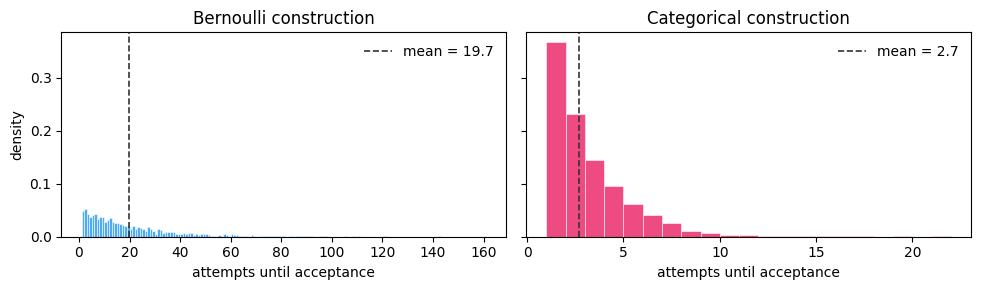

In [1]:
def rejection_bernoulli(w, n, rng):
    """Construction 1: independent coins, condition on size = n."""
    p = w / (1 + w)
    attempts = 0
    while True:
        attempts += 1
        S = np.where(rng.random(len(w)) < p)[0]
        if len(S) == n:
            return S, attempts

def rejection_categorical(w, n, rng):
    """Construction 2: n draws with replacement, condition on all distinct."""
    p = w / w.sum()
    attempts = 0
    while True:
        attempts += 1
        draws = rng.choice(len(w), size=n, replace=True, p=p)
        if len(set(draws)) == n:
            return np.sort(draws), attempts

import numpy as np
rng_rej = np.random.default_rng(42)
N_rej, n_rej = 20, 5
w_rej = rng_rej.exponential(1.0, N_rej)

trials = 2000
results = {}
for name, sampler in [('Bernoulli', rejection_bernoulli),
                       ('Categorical', rejection_categorical)]:
    results[name] = [sampler(w_rej, n_rej, rng_rej)[1] for _ in range(trials)]

fig, axes = pl.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, (name, attempts) in zip(axes, results.items()):
    ax.hist(attempts, bins=range(1, max(attempts) + 2), color='#2196F3' if name == 'Bernoulli' else '#E91E63',
            alpha=0.8, edgecolor='white', linewidth=0.5, density=True)
    ax.set_title(f'{name} construction', fontsize=12)
    ax.set_xlabel('attempts until acceptance')
    ax.axvline(np.mean(attempts), color='#333', ls='--', lw=1.2,
               label=f'mean = {np.mean(attempts):.1f}')
    ax.legend(frameon=False, fontsize=10)
axes[0].set_ylabel('density')
pl.tight_layout()
pl.show()

The acceptance rates for the two constructions are:

<table>
<thead>
<tr><th>Construction</th><th>Acceptance rate</th></tr>
</thead>
<tbody>
<tr><td>Bernoulli (condition on size $n$)</td><td>$\Pr[\text{exactly } n \text{ heads}] = \sum_{|S|=n} \prod_{i \in S} p_i \prod_{i \notin S}(1 - p_i)$</td></tr>
<tr><td>Categorical (condition on all distinct)</td><td>$n! \cdot \sum_{|S|=n} \prod_{i \in S} p_i$</td></tr>
</tbody>
</table>

where $p_i = \w_i/(1+\w_i)$ is the coin-flip probability for item $i$.

The Bernoulli acceptance rate is the most natural: it's just the probability that exactly $n$ of $N$ independent coins land heads—the normalizing constant of the conditional Poisson distribution.  In terms of the odds parameterization, it equals $\Z\tbinom{\bw}{n} / \prod_i(1 + \w_i)$, but this is just a reparameterization artifact. <a href="test_identities.py#test_bernoulli_acceptance_rate" title="test_bernoulli_acceptance_rate" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>

The categorical acceptance rate has an extra $n!$ <a href="test_identities.py#test_categorical_acceptance_rate" title="test_categorical_acceptance_rate" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a> because it draws an *ordered* tuple of $n$ items and there are $n!$ orderings of each size-$n$ set.

Both constructions produce the same conditional distribution.  The categorical version tends to be better when $n \ll N$ (collisions are rare—essentially the birthday problem), while the Bernoulli version can be better when the weights are spread out and $n/N$ is moderate.  **The gap.** Neither construction gives you a way to compute $\Z\tbinom{\bw}{n}$, the inclusion probabilities, or gradients for fitting — that's the gap the product tree fills.

## The polynomial product tree

The key idea is to encode the sum over all $\binom{N}{n}$ subsets as the coefficient of $\z^n$ in a product of polynomials:

$$
(1 + \w_1 \z)(1 + \w_2 \z) \cdots (1 + \w_N \z) = \sum_{k=0}^{N} \Z\tbinom{\bw}{k}\, \z^k
$$

The $n$-th coefficient is exactly $\Z\tbinom{\bw}{n}$, the normalizing constant. <a href="test_identities.py#test_product_polynomial_coefficients" title="test_product_polynomial_coefficients" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>  This product can be computed in $O(N \log^2 N)$ time using a divide-and-conquer strategy on a binary tree—a standard technique from computer algebra known as the *subproduct tree* (see [von zur Gathen & Gerhard (2013)](https://doi.org/10.1017/CBO9781139856065), Chapter 10).

**Notation.** We write $\llbracket f \rrbracket(\z^k)$ for the coefficient of $\z^k$ in a formal power series $f(\z) = \sum_k a_k \z^k$, i.e., $\llbracket f \rrbracket(\z^k) = a_k$.  This is sometimes written $[\z^k]\, f(\z)$; we use the Scott bracket notation to avoid ambiguity with other uses of square brackets.

### Upward pass

Each leaf of a complete binary tree holds one degree-1 polynomial $(1 + \w_i \z)$.  Internal nodes multiply their children's polynomials.  The root holds the full product, whose $n$-th coefficient is $\Z\tbinom{\bw}{n}$.

For example, with $N = 8$ items, the tree has three levels of internal nodes.  At the first level, pairs of leaves are multiplied: $P_{12}(\z) = (1 + \w_1 \z)(1 + \w_2 \z)$, and so on.  At the next level, $P_{1234} = P_{12} \cdot P_{34}$.  The root is $P_{12345678} = P_{1234} \cdot P_{5678}$.

```mermaid
graph BT
    L1["$$(1 + w_1 z)$$"] --> N12["$$P_{12} = P_1 \cdot P_2$$"]
    L2["$$(1 + w_2 z)$$"] --> N12
    L3["$$(1 + w_3 z)$$"] --> N34["$$P_{34} = P_3 \cdot P_4$$"]
    L4["$$(1 + w_4 z)$$"] --> N34
    L5["$$(1 + w_5 z)$$"] --> N56["$$P_{56} = P_5 \cdot P_6$$"]
    L6["$$(1 + w_6 z)$$"] --> N56
    L7["$$(1 + w_7 z)$$"] --> N78["$$P_{78} = P_7 \cdot P_8$$"]
    L8["$$(1 + w_8 z)$$"] --> N78
    N12 --> N1234["$$P_{1\text{-}4} = P_{12} \cdot P_{34}$$"]
    N34 --> N1234
    N56 --> N5678["$$P_{5\text{-}8} = P_{56} \cdot P_{78}$$"]
    N78 --> N5678
    N1234 --> ROOT["$$\text{root: } P_{1\text{-}8}$$"]
    N5678 --> ROOT

    style ROOT fill:#4a90d9,color:#fff
    style N1234 fill:#4a90d9,color:#fff
    style N5678 fill:#4a90d9,color:#fff
    style N12 fill:#4a90d9,color:#fff
    style N34 fill:#4a90d9,color:#fff
    style N56 fill:#4a90d9,color:#fff
    style N78 fill:#4a90d9,color:#fff
    style L1 fill:#e0e0e0,color:#000
    style L2 fill:#e0e0e0,color:#000
    style L3 fill:#e0e0e0,color:#000
    style L4 fill:#e0e0e0,color:#000
    style L5 fill:#e0e0e0,color:#000
    style L6 fill:#e0e0e0,color:#000
    style L7 fill:#e0e0e0,color:#000
    style L8 fill:#e0e0e0,color:#000
```

**Complexity.** At each level of the tree, the total size of the polynomials being multiplied is $O(N)$, and each multiplication is done via FFT in $O(d \log d)$ time where $d$ is the degree. The recurrence is

$$T(N) = 2\,T(N/2) + O(N \log N)$$

which solves to $T(N) = O(N \log^2 N)$ by the Master Theorem.

In [ ]:
# Worked example: N=4, n=2 — trace the upward and downward passes
from scipy.signal import convolve as poly_mul
from display_utils import html_table, poly_html
from IPython.display import HTML, display

w_ex = np.array([2.0, 3.0, 1.0, 5.0])
n_ex = 2

# ── Upward pass ──
P = {}
for i in range(4):
    P[i] = np.array([1.0, w_ex[i]])

P['L']  = poly_mul(P[0], P[1])       # (1+2z)(1+3z)
P['R']  = poly_mul(P[2], P[3])       # (1+z)(1+5z)
P['root'] = poly_mul(P['L'], P['R']) # full product

labels = {0: 'P₁', 1: 'P₂', 2: 'P₃', 3: 'P₄', 'L': 'P_L', 'R': 'P_R', 'root': 'P_root'}
rows = [(labels[k], poly_html(P[k])) for k in [0, 1, 'L', 2, 3, 'R', 'root']]
display(HTML('<h4>Upward pass</h4>'))
html_table(['node', 'polynomial'], rows)
Z = P['root'][n_ex]
check = sum(w_ex[i]*w_ex[j] for i in range(4) for j in range(i+1,4))
display(HTML(f'$Z(\\mathbf{{w}},2)$ = coeff of $z^2$ = <b>{Z:g}</b> &nbsp; (check: 2·3 + 2·1 + 2·5 + 3·1 + 3·5 + 1·5 = {check:g})'))

### Downward pass (backpropagation)

The upward pass computes the product $P_{\text{root}}(\z) = \prod_i (1 + \w_i \z)$.  To get inclusion probabilities, we need the *gradient* of this product with respect to each leaf.  As noted above, the inclusion probability is the [gradient of the log-normalizer](#Exponential-family-structure):

$$\pip_i = \frac{\partial \log \Z\tbinom{\bw}{n}}{\partial \theta_i} = \frac{\w_i \cdot \Z\tbinom{\bw^{(-i)}}{n-1}}{\Z\tbinom{\bw}{n}}$$

The numerator involves $\Z\tbinom{\bw^{(-i)}}{n-1}$, which is the $(n{-}1)$-th coefficient of the "leave-one-out" polynomial $P^{(-i)}(\z) = \prod_{j \neq i}(1 + \w_j \z)$.  So computing $\pip$ reduces to computing all $N$ leave-one-out products—which is exactly the [gradient of a product](https://timvieira.github.io/blog/gradient-of-a-product/).

This is not an analogy: the downward pass *is* [backpropagation](https://timvieira.github.io/blog/evaluating-fx-is-as-fast-as-fx/), applied to the tree-structured polynomial product.  The upward pass is the forward pass; the downward pass propagates adjoints (outside polynomials) from root to leaves using the standard reverse-mode rule for multiplication: the adjoint of a child is the parent's adjoint times the *sibling's* forward value.  By the [Baur-Strassen theorem](https://doi.org/10.1016/0304-3975(83)90110-X), this costs at most a constant factor more than the forward pass — so the downward pass is also $O(N \log^2 N)$.

Concretely: at the root, the "outside" polynomial is $1$.  When we descend to a child, its outside is the parent's outside times the sibling's inside polynomial.  The left child of the root gets outside $= P_{5678}$, the right child gets outside $= P_{1234}$.  Continuing down, leaf 1 gets outside $= P_{5678} \cdot P_2 \cdot P_{34} = P^{(-1)}$.  Each leaf ends up with the product of all *other* leaves' polynomials, without redundant work.

This is the same divide-and-conquer structure used for [heaps for incremental computation](https://timvieira.github.io/blog/heaps-for-incremental-computation/)—a balanced binary tree where each node stores an aggregate over its subtree, and updates propagate in $O(\log N)$—but here the "values" are polynomials and the "aggregation" is polynomial multiplication.

```mermaid
graph TB
    ROOT["$$\text{outside} = 1$$"] --> N1234["$$\text{outside} = P_{5\text{-}8}$$"]
    ROOT --> N5678["$$\text{outside} = P_{1\text{-}4}$$"]
    N1234 --> N12["$$\text{outside} = P_{5\text{-}8} \cdot P_{34}$$"]
    N1234 --> N34["$$\text{outside} = P_{5\text{-}8} \cdot P_{12}$$"]
    N5678 --> N56["$$\text{outside} = P_{1\text{-}4} \cdot P_{78}$$"]
    N5678 --> N78["$$\text{outside} = P_{1\text{-}4} \cdot P_{56}$$"]
    N12 --> L1["$$P^{(-1)} = \text{out}_{12} \cdot P_2$$"]
    N12 --> L2["$$P^{(-2)} = \text{out}_{12} \cdot P_1$$"]
    N34 --> L3["$$P^{(-3)} = \text{out}_{34} \cdot P_4$$"]
    N34 --> L4["$$P^{(-4)} = \text{out}_{34} \cdot P_3$$"]
    N56 --> L5["$$P^{(-5)} = \text{out}_{56} \cdot P_6$$"]
    N56 --> L6["$$P^{(-6)} = \text{out}_{56} \cdot P_5$$"]
    N78 --> L7["$$P^{(-7)} = \text{out}_{78} \cdot P_8$$"]
    N78 --> L8["$$P^{(-8)} = \text{out}_{78} \cdot P_7$$"]

    style ROOT fill:#4a90d9,color:#fff
    style N1234 fill:#4a90d9,color:#fff
    style N5678 fill:#4a90d9,color:#fff
    style N12 fill:#4a90d9,color:#fff
    style N34 fill:#4a90d9,color:#fff
    style N56 fill:#4a90d9,color:#fff
    style N78 fill:#4a90d9,color:#fff
    style L1 fill:#e0e0e0,color:#000
    style L2 fill:#e0e0e0,color:#000
    style L3 fill:#e0e0e0,color:#000
    style L4 fill:#e0e0e0,color:#000
    style L5 fill:#e0e0e0,color:#000
    style L6 fill:#e0e0e0,color:#000
    style L7 fill:#e0e0e0,color:#000
    style L8 fill:#e0e0e0,color:#000
```

The inclusion probability is then:

$$
\pip_i = \w_i \cdot \llbracket P^{(-i)} \rrbracket(\z^{n-1}) \;/\; \Z\tbinom{\bw}{n}
$$

where $\llbracket f \rrbracket(\z^k)$ denotes the coefficient of $\z^k$ in the formal power series $f$.

In [ ]:
# ── Downward pass ──
oP = {}
oP['root'] = np.array([1.0])
oP['L']  = P['R']
oP['R']  = P['L']
oP[0] = poly_mul(oP['L'], P[1])
oP[1] = poly_mul(oP['L'], P[0])
oP[2] = poly_mul(oP['R'], P[3])
oP[3] = poly_mul(oP['R'], P[2])

display(HTML('<h4>Downward pass (leave-one-out polynomials)</h4>'))
rows = []
for i in range(4):
    coeff = oP[i][n_ex - 1]
    rows.append((f'P<sup>(−{i+1})</sup>', poly_html(oP[i]), f'{coeff:g}'))
html_table(['leave-one-out', 'polynomial', f'coeff of z<sup>{n_ex-1}</sup>'], rows)

### Sampling

Sampling reuses the upward-pass tree (no downward pass needed).  Starting at the root with a quota of $k = n$ items to select, we walk top-down: at each internal node, randomly split the quota between the left and right subtrees.  The probability of assigning $j$ items to the left is proportional to $\llbracket P_L \rrbracket(\z^j) \cdot \llbracket P_R \rrbracket(\z^{k-j})$.  This is exact, not approximate — it follows from the **weighted Vandermonde identity**: $\Z\tbinom{(\ba, \bb)}{k} = \sum_{j=0}^{k} \Z\tbinom{\ba}{j} \cdot \Z\tbinom{\bb}{k-j}$, which says the number of ways to choose $k$ items from $A \cup B$ is the convolution of the two groups' counts.  Each term in the sum is the conditional probability of a particular left/right split.  At the leaves, quota 1 means "include this item"; quota 0 means "exclude."

```mermaid
graph TB
    ROOT["$$\text{quota} = n$$"] -->|"$$j_1 \text{ items}$$"| LEFT["$$\text{quota} = j_1$$"]
    ROOT -->|"$$n - j_1 \text{ items}$$"| RIGHT["$$\text{quota} = n - j_1$$"]
    LEFT -->|"$$j_2$$"| LL["$$\text{quota} = j_2$$"]
    LEFT -->|"$$j_1 - j_2$$"| LR["$$\text{quota} = j_1 - j_2$$"]
    RIGHT -->|"$$j_3$$"| RL["$$\text{quota} = j_3$$"]
    RIGHT -->|"$$n - j_1 - j_3$$"| RR["$$\text{quota} = n - j_1 - j_3$$"]
    LL --> L1["$$0 \text{ or } 1$$"]
    LL --> L2["$$0 \text{ or } 1$$"]
    LR --> L3["$$0 \text{ or } 1$$"]
    LR --> L4["$$0 \text{ or } 1$$"]
    RL --> L5["$$0 \text{ or } 1$$"]
    RL --> L6["$$0 \text{ or } 1$$"]
    RR --> L7["$$0 \text{ or } 1$$"]
    RR --> L8["$$0 \text{ or } 1$$"]

    style ROOT fill:#4a90d9,color:#fff
    style LEFT fill:#4a90d9,color:#fff
    style RIGHT fill:#4a90d9,color:#fff
    style LL fill:#4a90d9,color:#fff
    style LR fill:#4a90d9,color:#fff
    style RL fill:#4a90d9,color:#fff
    style RR fill:#4a90d9,color:#fff
    style L1 fill:#e0e0e0,color:#000
    style L2 fill:#e0e0e0,color:#000
    style L3 fill:#e0e0e0,color:#000
    style L4 fill:#e0e0e0,color:#000
    style L5 fill:#e0e0e0,color:#000
    style L6 fill:#e0e0e0,color:#000
    style L7 fill:#e0e0e0,color:#000
    style L8 fill:#e0e0e0,color:#000
```

In pseudocode:

```python
def sample(node, quota):
    if node.is_leaf:
        return [node.item] if quota == 1 else []
    # P_L[j] * P_R[quota-j] for j = 0, ..., quota
    probs = [node.left.poly[j] * node.right.poly[quota - j]
             for j in range(quota + 1)]
    j = categorical(probs)              # how many items from the left subtree
    return sample(node.left, j) + sample(node.right, quota - j)

S = sample(root, n)                     # exactly n items
```

The tree is built once ($O(N \log^2 N)$) and reused for each sample ($O(n \log N)$ per sample)—at each of the $O(\log N)$ levels, only nodes whose quota is nonzero are visited, and there are at most $n$ such nodes.  (When $n \approx N$, nearly all nodes are visited, so the per-sample cost approaches $O(N \log N)$.)  No $\binom{N}{n}$-sized table is ever constructed.

In [ ]:
# ── Inclusion probabilities ──
pi_ex = np.array([w_ex[i] * oP[i][n_ex - 1] / Z for i in range(4)])
display(HTML('<h4>Inclusion probabilities</h4>'))
rows = []
for i in range(4):
    rows.append((f'{i+1}', f'{w_ex[i]:g}', f'{oP[i][n_ex-1]:g}', f'{pi_ex[i]:.4f}'))
html_table(
    ['$i$', '$w_i$', f'$[z^{{{n_ex-1}}}]\\, P^{{(-i)}}$', '$\\pi_i = w_i \\cdot [\\cdot] / Z$'],
    rows,
    caption=f'$\\sum \\pi_i = {pi_ex.sum():.4f}$ (should be {n_ex})',
)

cp_ex = ConditionalPoisson.from_weights(n_ex, w_ex)
assert np.allclose(pi_ex, cp_ex.pi), "MISMATCH!"

<details>
<summary><b>Brute-force verification</b> (click to expand)</summary>

For small instances, we can enumerate all $\binom{N}{n}$ subsets and verify that the efficient algorithm gets the right answer.  (See also the test suite in `test_conditional_poisson.py`.)

</details>

In [8]:
from itertools import combinations
from display_utils import html_table, check_mark
from IPython.display import HTML, display

N_small, n_small = 7, 3
rng_bf = np.random.default_rng(42)
w_small = rng_bf.exponential(1.0, N_small)
cp_small = ConditionalPoisson.from_weights(n_small, w_small)

# Brute force: enumerate all subsets
all_S = list(combinations(range(N_small), n_small))
log_unnorm = np.array([np.log(np.prod(w_small[list(s)])) for s in all_S])
log_Z_bf = np.log(np.exp(log_unnorm).sum())
log_probs_bf = log_unnorm - log_Z_bf           # normalize

probs_bf = np.exp(log_probs_bf)
pi_bf = np.zeros(N_small)
for k, s in enumerate(all_S):
    for i in s:
        pi_bf[i] += probs_bf[k]

pi_err = np.max(np.abs(cp_small.pi - pi_bf))
z_err = abs(cp_small.log_normalizer - log_Z_bf)

html_table(
    ['check', 'value', ''],
    [
        ('max |π_tree − π_brute_force|', f'{pi_err:.2e}', check_mark(pi_err < 1e-12)),
        ('∑ P(S) via brute force', f'{probs_bf.sum():.10f}', check_mark(abs(probs_bf.sum() - 1) < 1e-10)),
        ('log Z (tree)', f'{cp_small.log_normalizer:.6f}', ''),
        ('log Z (brute force)', f'{log_Z_bf:.6f}', check_mark(z_err < 1e-10)),
    ],
    caption=f'Brute-force verification (N={N_small}, n={n_small})',
)

check,value,
max |π_tree − π_brute_force|,2.22e-16,✓
∑ P(S) via brute force,1.0000000000,✓
log Z (tree),2.882672,
log Z (brute force),2.882672,✓


## Basic usage

Now that we've seen how the product tree works under the hood, here's the library interface.  The simplest entry point is `from_weights`: hand it a subset size $n$ and a weight vector $\bw$.

In [3]:
N, n = 10, 4
rng = np.random.default_rng(0)
w = rng.exponential(1.0, N)

cp = ConditionalPoisson.from_weights(n, w)

from display_utils import html_table
from IPython.display import HTML, display

rows = list(zip(
    range(N),
    [f'{wi:.4f}' for wi in w],
    [f'{pi:.4f}' for pi in cp.pi],
))
html_table(
    ['$i$', '$w_i$', '$\pi_i$'],
    rows,
    caption=f'$N={N}, \; n={n}, \;$ $\log Z = {cp.log_normalizer:.4f}, \;$ $\sum \pi_i = {cp.pi.sum():.4f}$',
)

The inclusion probabilities $\pip_i = P(i \in S)$ always sum to $n$ <a href="test_identities.py#test_pi_sums_to_n" title="test_pi_sums_to_n" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>, and each $\pip_i \in [0, 1]$ <a href="test_identities.py#test_pi_in_unit_interval" title="test_pi_in_unit_interval" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>.  Items with larger weights get higher inclusion probabilities.

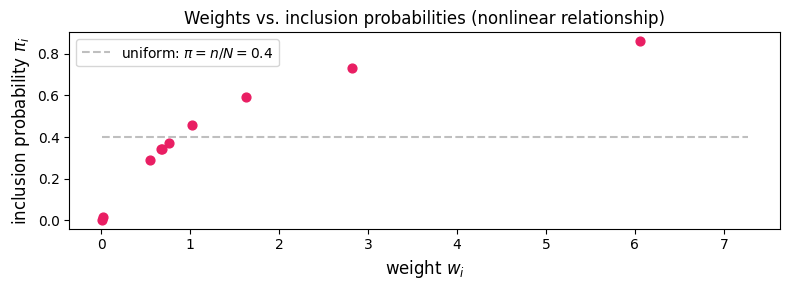

In [4]:
pl.figure(figsize=(8, 3))
pl.scatter(w, cp.pi, color='#E91E63', s=40, zorder=3)
w_grid = np.linspace(w.min() * 0.8, w.max() * 1.2, 200)
cp_grid = ConditionalPoisson.from_weights(n, w)
# Show what pi_i would be if all weights were equal to w_grid[j]
pi_uniform = n / N * np.ones_like(w_grid)  # uniform baseline
pl.plot(w_grid, pi_uniform, '--', color='gray', alpha=0.5, label=f'uniform: $\\pi = n/N = {n/N:.1f}$')
pl.xlabel('weight $w_i$', fontsize=12)
pl.ylabel('inclusion probability $\\pi_i$', fontsize=12)
pl.title('Weights vs. inclusion probabilities (nonlinear relationship)', fontsize=12)
pl.legend()
pl.tight_layout()
pl.show()

## Sampling

Drawing samples works by walking a binary tree top-down, splitting a "quota" of $n$ items between the left and right subtrees at each node.  Each split is exact (not approximate) <a href="test_identities.py#test_sampling_distribution" title="test_sampling_distribution" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>, and the tree is built once and cached, so subsequent samples are cheap.

In [5]:
M = 100_000
samples = cp.sample(M, rng=rng)

from IPython.display import HTML, display
display(HTML(
    f'<b>{M:,} samples</b> of size <b>{samples.shape[1]}</b> '
    f'&mdash; first 5: '
    + ', '.join('{' + ','.join(map(str, s)) + '}' for s in samples[:5])
))

Let's verify that the empirical inclusion frequencies match the exact $\pip$ values.

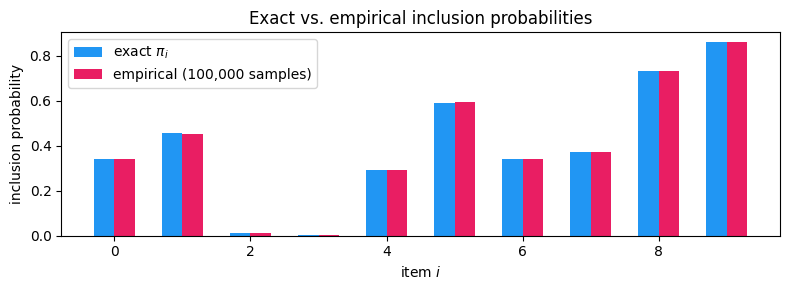

In [6]:
pi_emp = np.bincount(samples.ravel(), minlength=N) / M

pl.figure(figsize=(8, 3))
ix = np.arange(N)
pl.bar(ix - 0.15, cp.pi, width=0.3, label='exact $\pi_i$', color='#2196F3')
pl.bar(ix + 0.15, pi_emp, width=0.3, label=f'empirical ({M:,} samples)', color='#E91E63')
pl.xlabel('item $i$')
pl.ylabel('inclusion probability')
pl.legend()
pl.title('Exact vs. empirical inclusion probabilities')
pl.tight_layout()

## Fitting weights to target probabilities

A common use case: you know the inclusion probabilities you *want* (e.g., from a survey design or an optimal allocation), and you need to find weights that produce them. <a href="test_identities.py#test_fitting_recovers_target" title="test_fitting_recovers_target" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>

**Objective.** Since $\log P(S) = \sum_{i \in S} \theta_i - \log \Z\tbinom{\bw}{n}$, we maximize the expected log-probability under the target marginals:

$$
L(\theta) = \pip^{*\top} \theta - \log \Z\tbinom{\bw}{n}
$$

This is convex because $\log \Z$ is the log-partition function of the [exponential family](#Exponential-family-structure).

**Gradient.** The gradient is $\pip^* - \pip(\theta)$ <a href="test_identities.py#test_fitting_gradient" title="test_fitting_gradient" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a> — the difference between the target and current inclusion probabilities.  At the optimum, $\pip(\theta) = \pip^*$ exactly.

**Hessian.** The Hessian is $-\text{Cov}[\mathbf{1}_S]$, the negative covariance matrix of the inclusion indicators.  This is negative semi-definite (as required for a concave objective) and has rank $N - 1$ — the null space is $\text{span}\{\mathbf{1}\}$ because shifting all log-weights by a constant doesn't change the distribution.

**Newton-CG and the D-tree.** We use Newton-CG, which needs Hessian-vector products $\text{Cov}[\mathbf{1}_S]\, v$ but never the full $N \times N$ Hessian.  This is where the **D-tree** comes in — it is [Pearlmutter's R-operator](https://doi.org/10.1162/neco.1994.6.1.147) (forward-mode AD) applied to the backward pass, giving us the Hessian-vector product for another $O(1)\times$ factor beyond the gradient.

The pattern is a mechanical sequence of program transformations, each with a known cost guarantee:

| Pass | Computes | Technique | Cost |
|---|---|---|---|
| Forward (upward) | $\Z$ | tree-structured polynomial multiply | $O(N \log^2 N)$ |
| Backward (downward) | $\pip = \nabla_\theta \log \Z$ | reverse-mode AD / backprop ([Baur & Strassen, 1983](https://doi.org/10.1016/0304-3975(83)90110-X)) | $O(N \log^2 N)$ |
| R-operator | $\text{Cov}[\mathbf{1}_S]\, v$ | forward-mode AD of backward pass ([Pearlmutter, 1994](https://doi.org/10.1162/neco.1994.6.1.147)) | $O(N \log^2 N)$ |

Concretely, where the P-tree computes $P_T(\z) = \prod_{i \in T}(1 + \w_i \z)$, the D-tree computes its directional derivative $D_T(\z) = \sum_{i \in T} v_i \w_i \prod_{j \in T, j \neq i}(1 + \w_j \z)$ using the product rule at each internal node: $D[\text{node}] = D[L] \cdot P[R] + P[L] \cdot D[R]$ <a href="test_identities.py#test_dtree_product_rule" title="test_dtree_product_rule" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>.  A joint downward pass then delivers both $P^{(-i)}$ and $D^{(-i)}$ at every leaf, giving the full Hessian-vector product in $O(N \log^2 N)$.

<details>
<summary><b>Warm start: why logit(π*) is a good initialization</b> (click to expand)</summary>

The optimizer is initialized at $\theta_i = \log(\pip^*_i / (1 - \pip^*_i))$, i.e., the odds of the target inclusion probabilities.  This is the exact solution in the *unconditional* Poisson case: if we flip independent coins with $p_i = \pip^*_i$, the odds are $\w_i = p_i/(1-p_i)$ and the expected sample size is $\sum \pip^*_i = n$.  Conditioning on the sample size being exactly $n$ perturbs the inclusion probabilities, but the perturbation is small.

Hájek (1964, Theorem 5.2) showed that under standard regularity conditions, the conditional Poisson inclusion probabilities satisfy

$$\pip_i = p_i + O(1/N)$$

where $p_i = \w_i/(1+\w_i)$ are the unconditional Poisson probabilities.  [Boistard, Lopuhaä & Ruiz-Gazen (2012)](https://arxiv.org/abs/1207.5654) give the explicit correction term:

$$\pip_i = p_i\Big(1 - d^{-1}(p_i - \bar{p})(1 - p_i) + O(d^{-2})\Big)$$

where $d = \sum_i p_i(1-p_i)$ is the variance of the Poisson sample size and $\bar{p} = d^{-1}\sum_i p_i^2(1-p_i)$.  Under the regularity condition $\limsup N/d < \infty$ (which holds whenever the $p_i$ are bounded away from 0 and 1), we have $d = \Theta(N)$, so the initialization error is $O(1/N)$ — essentially exact for large $N$, and a good starting point for Newton's method at any $N$.

</details>

In [9]:
# Target: the inclusion probabilities from our earlier example
pi_star = cp.pi.copy()

# Fit from scratch
cp_fit = ConditionalPoisson.fit(pi_star, n, verbose=True)

  iter   0:  max|pi*-pi| = 3.332e-02
  iter   1:  max|pi*-pi| = 2.606e-03
  iter   2:  max|pi*-pi| = 2.036e-05
  iter   3:  max|pi*-pi| = 1.994e-09
  iter   4:  max|pi*-pi| = 7.661e-15


max |pi_fit - pi_target| = 8.27e-15


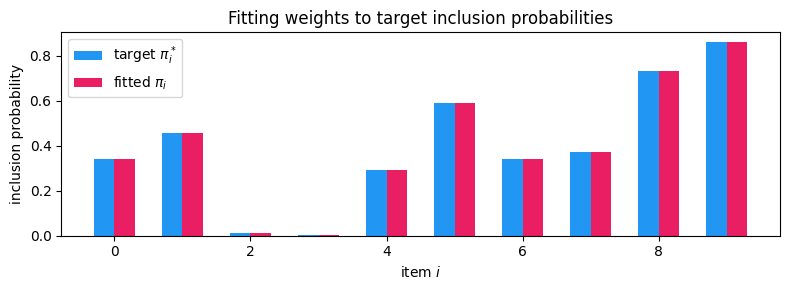

In [10]:
print(f'max |pi_fit - pi_target| = {np.max(np.abs(cp_fit.pi - pi_star)):.2e}')

pl.figure(figsize=(8, 3))
ix = np.arange(N)
pl.bar(ix - 0.15, pi_star, width=0.3, label='target $\pi^*_i$', color='#2196F3')
pl.bar(ix + 0.15, cp_fit.pi, width=0.3, label='fitted $\pi_i$', color='#E91E63')
pl.xlabel('item $i$')
pl.ylabel('inclusion probability')
pl.legend()
pl.title('Fitting weights to target inclusion probabilities')
pl.tight_layout()

## Numerical stability

Every polynomial in the tree is stored in a scaled representation `(coeffs, log_scale)` with $\max|c_k| = 1$, so FFT convolutions always operate on $O(1)$-magnitude numbers—let's verify with some stress tests.

In [11]:
from display_utils import html_table, check_mark

cases = [
    ('large positive θ',       ConditionalPoisson(4, rng.uniform(30, 50, 10))),
    ('large negative θ',       ConditionalPoisson(4, rng.uniform(-50, -30, 10))),
    ('wide range θ',           ConditionalPoisson(4, np.linspace(-30, 30, 10))),
    ('N=100, n=50, uniform',   ConditionalPoisson(50, np.full(100, 2.0))),
    ('N=200, n=100, uniform',  ConditionalPoisson(100, np.full(200, 10.0))),
    ('N=500, n=250, uniform',  ConditionalPoisson(250, np.full(500, 5.0))),
]

rows = []
for name, cpt in cases:
    pi_t = cpt.pi
    ok = (np.isfinite(pi_t).all() and np.isfinite(cpt.log_normalizer)
          and abs(pi_t.sum() - cpt.n) < 1e-4)
    rows.append((name, f'{pi_t.sum():.4f}', f'{cpt.log_normalizer:.2f}', check_mark(ok)))

html_table(['case', '∑ π', 'log Z', ''], rows, caption='Numerical stability across extreme regimes')

case,∑ π,log Z,
large positive θ,4.0000,185.40,✓
large negative θ,4.0000,-138.80,✓
wide range θ,4.0000,80.00,✓
"N=100, n=50, uniform",50.0000,166.78,✓
"N=200, n=100, uniform",100.0000,1135.75,✓
"N=500, n=250, uniform",250.0000,1593.24,✓


## Timing

The tree-based approach scales to moderately large $N$ comfortably.  For comparison, the naive $O(N^2 n)$ DP baseline is also shown.  (The PyTorch FFT implementation in the next section is significantly faster—see below.)

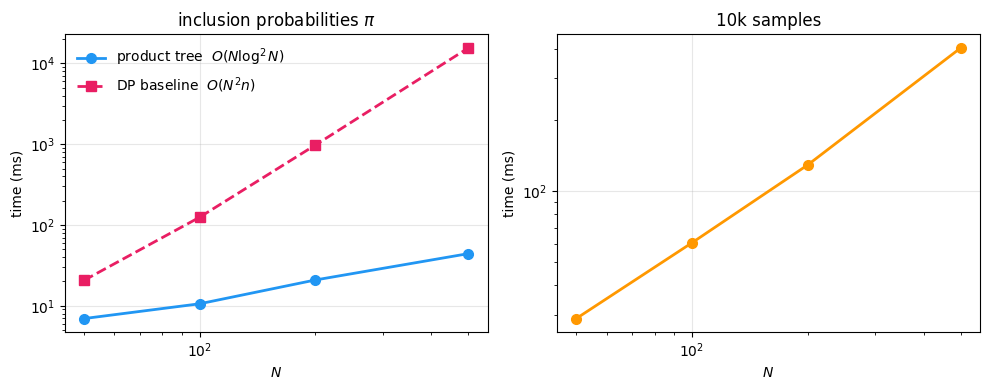

In [12]:
import time

def dp_pi(w, n):
    """O(N^2 n) DP for inclusion probabilities (baseline)."""
    N = len(w)
    e = np.zeros((N + 1, n + 1))
    e[0, 0] = 1.0
    for m in range(N):
        e[m + 1, 0] = e[m, 0]
        for k in range(1, n + 1):
            e[m + 1, k] = e[m, k] + w[m] * e[m, k - 1]
    Z = e[N, n]
    pi = np.empty(N)
    for i in range(N):
        ei = np.zeros(n)
        ei[0] = 1.0
        for m in range(N):
            if m == i:
                continue
            for k in range(min(n - 1, m + 1), 0, -1):
                ei[k] += w[m] * ei[k - 1]
        pi[i] = w[i] * ei[n - 1] / Z
    return pi

sizes = [(50, 20), (100, 40), (200, 80), (500, 200)]
Ns, tree_ms, dp_ms, samp_ms = [], [], [], []

for N_t, n_t in sizes:
    w_t = rng.exponential(1.0, N_t)
    cp_t = ConditionalPoisson.from_weights(n_t, w_t)
    reps = max(1, int(800 / (N_t * n_t**0.5)))

    t0 = time.perf_counter()
    for _ in range(reps): cp_t._cache.clear(); cp_t.pi
    t_tree = (time.perf_counter() - t0) / reps * 1000

    dp_reps = max(1, reps // 2) if N_t <= 200 else 1
    t0 = time.perf_counter()
    for _ in range(dp_reps): dp_pi(w_t, n_t)
    t_dp = (time.perf_counter() - t0) / dp_reps * 1000

    t0 = time.perf_counter()
    cp_t.sample(10_000, rng=rng)
    t_samp = (time.perf_counter() - t0) * 1000

    Ns.append(N_t)
    tree_ms.append(t_tree)
    dp_ms.append(t_dp)
    samp_ms.append(t_samp)

fig, (ax1, ax2) = pl.subplots(1, 2, figsize=(10, 4))

# Left: tree vs DP for computing pi
ax1.loglog(Ns, tree_ms, 'o-', color='#2196F3', label='product tree  $O(N \log^2 N)$', lw=2, ms=7)
ax1.loglog(Ns, dp_ms, 's--', color='#E91E63', label='DP baseline  $O(N^2 n)$', lw=2, ms=7)
ax1.set_xlabel('$N$')
ax1.set_ylabel('time (ms)')
ax1.set_title('inclusion probabilities $\pi$')
ax1.legend(frameon=False, fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: sampling
ax2.loglog(Ns, samp_ms, 'o-', color='#FF9800', lw=2, ms=7)
ax2.set_xlabel('$N$')
ax2.set_ylabel('time (ms)')
ax2.set_title('10k samples')
ax2.grid(True, alpha=0.3)

pl.tight_layout()
pl.show()

## PyTorch implementation with contour scaling

The NumPy implementation above uses hand-coded upward and downward passes with `scipy.signal.convolve`.  A natural question: can we use PyTorch's autograd to compute the gradient (inclusion probabilities) and Hessian-vector product automatically, given only the forward pass?

The answer is yes—and it's both simpler and faster.  The key insight is that **the downward pass is just backpropagation** applied to the upward pass.  The [Baur-Strassen theorem](https://timvieira.github.io/blog/evaluating-fx-is-as-fast-as-fx/) guarantees that the gradient costs $O(1)\times$ the forward pass, and [Pearlmutter's R-operator](https://doi.org/10.1162/neco.1994.6.1.147) gives us the Hessian-vector product for another $O(1)\times$ factor.  [Griewank & Walther (2008)](https://doi.org/10.1137/1.9780898717761) show that the numerical stability of the derivatives is inherited from the forward pass—so if we make the forward pass stable, everything else follows.

The forward pass is just the product tree: build $\prod_i (1 + \w_i \z)$ bottom-up using polynomial multiplication, then extract $[\z^n]$ and take the log.  In PyTorch, we batch all multiplications at each tree level into a single operation—$O(\log N)$ torch calls instead of $O(N)$.

### The FFT precision problem and contour scaling

Using FFT for the polynomial multiplications gives $O(N \log^2 n)$ complexity (with truncation to degree $n$).  But naively, FFT introduces rounding errors $\sim \varepsilon \cdot \max|c_k|$ per coefficient.  The product polynomial's peak coefficient (near degree $N/2$) can be $\sim 10^{300}$ times larger than the coefficient at degree $n$—so FFT noise drowns the signal.

The fix: **contour radius scaling**.  Replace each weight $\w_i \mapsto \w_i \cdot r$ before building the tree, where $r$ is chosen to shift the peak of the product polynomial to degree $n$.  The $n$-th coefficient of $\prod_i(1 + \w_i r \z)$ equals $\Z\tbinom{\bw}{n} \cdot r^n$, so we recover $\log \Z = \log(\text{root}[n]) - n \log r$. <a href="test_identities.py#test_contour_scaling" title="test_contour_scaling" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>

The optimal $r = e^t$ where $t$ solves:

$$\sum_i \frac{\w_i \cdot r}{1 + \w_i \cdot r} = n$$

This is the **Lagrange multiplier** from the Poisson sampling connection: under Poisson sampling with coin-flip probabilities $p_i = \w_i r / (1 + \w_i r)$, the expected sample size is exactly $n$. <a href="test_identities.py#test_contour_r_solves_expected_size" title="test_contour_r_solves_expected_size" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>  After rescaling, the product polynomial's peak falls at degree $n$, so FFT errors are relative to the coefficient we actually need.  After rescaling, all coefficients are within a modest factor of the $n$-th coefficient, so FFT rounding errors stay well below machine epsilon.

The rescaling $\w_i \mapsto \w_i \cdot r$ is on the autograd graph (it's just a scalar multiply); the root-finding for $r$ is not (it's a numerical conditioning choice, not part of the mathematical function).

In [13]:
import torch
from torch_fft_prototype import forward_log_Z, compute_pi, compute_hvp

# Verify correctness against the NumPy implementation
theta_test = np.log(w)  # reuse weights from earlier
theta_t = torch.tensor(theta_test, dtype=torch.float64)

pi_fft = compute_pi(theta_t, n).detach().numpy()
print(f'max |pi_fft - pi_numpy| = {np.max(np.abs(cp.pi - pi_fft)):.2e}')

v_test = rng.standard_normal(N)
v_t = torch.tensor(v_test, dtype=torch.float64)
hvp_fft = compute_hvp(theta_t, n, v_t).detach().numpy()
print(f'max |hvp_fft - hvp_numpy| = {np.max(np.abs(cp.hvp(v_test) - hvp_fft)):.2e}')

# Verify autograd works end-to-end
theta_grad = torch.tensor(theta_test, dtype=torch.float64, requires_grad=True)
log_Z = forward_log_Z(theta_grad, n)
log_Z.backward()
print(f'autograd: log_Z differentiable = {log_Z.grad_fn is not None}')
print(f'autograd: theta.grad finite    = {torch.isfinite(theta_grad.grad).all().item()}')

max |pi_fft - pi_numpy| = 1.33e-15
max |hvp_fft - hvp_numpy| = 3.66e-15
autograd: log_Z differentiable = True
autograd: theta.grad finite    = True


### Timing

The FFT-based PyTorch implementation is significantly faster than the NumPy version, especially at large $N$:

In [14]:
import time as _time

print(f'{"N":>6s}  {"n":>5s}  {"NumPy pi":>10s}  {"FFT pi":>10s}  {"speedup":>8s}  {"FFT hvp":>10s}')
print('-' * 60)
for N_t, n_t in [(100, 40), (500, 200), (1000, 400), (2000, 800), (5000, 2000)]:
    theta_np = rng.standard_normal(N_t) * 0.5
    v_np = rng.standard_normal(N_t)
    theta_t = torch.tensor(theta_np, dtype=torch.float64)
    v_t = torch.tensor(v_np, dtype=torch.float64)
    cp_t = ConditionalPoisson(n_t, theta_np)
    reps = max(3, 50 // max(1, N_t // 100))

    for _ in range(3): cp_t._cache.clear(); cp_t.pi
    t0 = _time.perf_counter()
    for _ in range(reps): cp_t._cache.clear(); cp_t.pi
    t_np = (_time.perf_counter() - t0) / reps

    for _ in range(3): compute_pi(theta_t, n_t)
    t0 = _time.perf_counter()
    for _ in range(reps): compute_pi(theta_t, n_t)
    t_fft = (_time.perf_counter() - t0) / reps

    for _ in range(3): compute_hvp(theta_t, n_t, v_t)
    t0 = _time.perf_counter()
    for _ in range(reps): compute_hvp(theta_t, n_t, v_t)
    t_hvp = (_time.perf_counter() - t0) / reps

    print(f'{N_t:>6d}  {n_t:>5d}  {t_np*1000:>8.0f}ms  {t_fft*1000:>8.0f}ms  {t_np/t_fft:>7.1f}x  {t_hvp*1000:>8.0f}ms')

     N      n    NumPy pi      FFT pi   speedup     FFT hvp
------------------------------------------------------------
   100     40        11ms         6ms      1.9x        17ms
   500    200        47ms        17ms      2.9x        51ms
  1000    400       109ms        25ms      4.4x        70ms
  2000    800       279ms        39ms      7.1x       160ms
  5000   2000      1442ms       106ms     13.6x       399ms


The speedup comes from three sources:

1. **FFT-based polynomial multiplication**: $O(d \log d)$ per multiply instead of $O(d^2)$, giving $O(N \log^2 n)$ total with truncation to degree $n$.

2. **Batched execution**: all multiplications at each tree level are batched into a single torch operation ($O(\log N)$ torch calls, not $O(N)$).

3. **Autograd**: the gradient (inclusion probabilities) and Hessian-vector product come from backpropagation—no hand-coded downward pass or D-tree needed.

The contour scaling is essential: without it, FFT precision collapses at $N \gtrsim 1000$.  With it, the implementation achieves machine-epsilon accuracy at all tested sizes ($N$ up to 10,000) and handles extreme weight ranges ($r$ from $10^{-10}$ to $10^{8}$).

Code: [`torch_fft_prototype.py`](https://github.com/timvieira/conditional-poisson-sampling)

## Application: Horvitz-Thompson estimation

So far we've built machinery for sampling fixed-size subsets and computing inclusion probabilities.  A natural question: what can you *do* with this?  One important application is unbiased estimation.

**Setup.** Suppose you have a distribution $p$ over a universe $\mathcal{S}$ of $N$ items, and a function $f$ that is expensive to evaluate.  You want to estimate $\mu = \sum_i p(i)\, f(i)$ using only $n$ evaluations of $f$.  With i.i.d. Monte Carlo, you'd draw $n$ samples — but some items may repeat, wasting evaluations.

**The estimator.** The **Horvitz-Thompson estimator** ([Horvitz & Thompson, 1952](https://doi.org/10.1080/01621459.1952.10483446)) uses sampling *without* replacement to guarantee $n$ *distinct* evaluations.  Draw a fixed-size subset $S \sim P_n$ using CPS, then form:

$$
\hat{\mu}_{\text{HT}}(S) = \sum_{i \in S} \frac{p(i)}{\pip_i}\, f(i), \quad S \sim P_n
$$

The inverse-probability weighting $p(i)/\pip_i$ corrects for the sampling bias — items with higher inclusion probability are down-weighted, and vice versa.

**Example.** With $N = 100$ items and $n = 5$, set weights proportional to $p(i)$ so that high-probability items are more likely to be selected.  Each sample gives 5 distinct evaluations of $f$; the HT formula reweights them to produce an unbiased estimate of the full sum.

gives an unbiased estimate: $\mathbb{E}[\hat{\mu}_{\text{HT}}] = \mu$ <a href="test_identities.py#test_horvitz_thompson_unbiased" title="test_horvitz_thompson_unbiased" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>, provided $\pip_i > 0$ whenever $p(i) > 0$.

The advantage over Monte Carlo (i.i.d. sampling): MC wastes evaluations resampling high-probability elements, while SWOR guarantees $n$ *distinct* evaluations.  CPS makes this practical because we can efficiently compute both the samples and the inclusion probabilities $\pip_i$ that the estimator needs.

For more on SWOR-based estimation (including the near-optimal priority sampling scheme), see my earlier post on [estimating means in a finite universe](https://timvieira.github.io/blog/post/2017/07/03/estimating-means-in-a-finite-universe/).

## Identities for $\Z$ and its relatives

The normalizing constant $\Z\tbinom{\bw}{n}$ is the $n$-th elementary symmetric polynomial $e_n(\bw)$.  Here are some useful identities.

### Parameterizations

The conditional Poisson distribution arises from Poisson sampling—flip $N$ independent coins with $\Pr[\text{heads}_i] = p_i$, condition on exactly $n$ heads.  There are two natural parameterizations:

| | Probability $p_i$ | Odds $\w_i$ |
|---|---|---|
| **Parameter** | $\boldsymbol{p} \in [0,1]^N$ | $\bw \in [0,\infty)^N$ where $\w_i = p_i/(1-p_i)$ |
| **Leaf polynomial** | $(1-p_i) + p_i\, \z$ | $1 + \w_i\, \z$ |
| **Generating function** | $\prod_i\big((1-p_i) + p_i \z\big) = \sum_k \Pr[k \text{ heads}]\, \z^k$ | $\prod_i(1 + \w_i \z) = \sum_k \Z\tbinom{\bw}{k} \z^k$ |
| **$k$-th coefficient** | $\Pr[\text{exactly } k \text{ heads}]$ | $\Z\tbinom{\bw}{k}$ |

These are **probability generating functions** (PGFs) for the random variable $K = |S|$ (the number of heads in $N$ independent coin flips): the coefficient of $\z^k$ is the probability (or unnormalized weight) that exactly $k$ items are selected.  The formal variable $\z$ is a bookkeeping device—it "marks" each included item so that the coefficient-extraction operator $\llbracket \cdot \rrbracket(\z^k)$ picks out the contribution from exactly $k$ items.

The two generating functions are related by factoring out $\prod_i(1-p_i) = 1/\prod_i(1+\w_i)$:

$$\prod_i\big((1-p_i) + p_i \z\big) = \prod_i(1-p_i) \cdot \prod_i(1 + \w_i \z)$$

so $\Pr[k \text{ heads}] = \Z\tbinom{\bw}{k} / \prod_i(1+\w_i)$. <a href="test_identities.py#test_prob_odds_generating_function_relation" title="test_prob_odds_generating_function_relation" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>

The odds parameterization is more convenient for computation (the leaf polynomial $1 + \w_i \z$ is monic), while the probability parameterization is more natural for interpretation (the normalizer is literally $\Pr[n \text{ heads}]$).  The conditional distribution is the same either way—scaling all weights by $\alpha > 0$ doesn't change it. <a href="test_identities.py#test_scaling_invariance" title="test_scaling_invariance" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>

### Differential identities

As discussed in the [downward pass section](#Downward-pass-(backpropagation)), the inclusion probability is the [gradient of the log-normalizer](#Exponential-family-structure):

$$\pip_i = \frac{\partial \log \Z}{\partial \theta_i} = \frac{\w_i \cdot \Z\tbinom{\bw^{(-i)}}{n-1}}{\Z\tbinom{\bw}{n}}$$
<a href="test_identities.py#test_pi_is_gradient_of_log_Z" title="test_pi_is_gradient_of_log_Z, test_pi_leave_one_out, test_pi_matches_brute_force" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>

The second derivative gives the covariance matrix of the inclusion indicators:

$$\text{Cov}[\mathbf{1}_{i \in S},\, \mathbf{1}_{j \in S}] = \frac{\partial^2 \log \Z}{\partial \theta_i \partial \theta_j}$$
<a href="test_identities.py#test_covariance_is_hessian" title="test_covariance_is_hessian" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>

This Hessian is what the D-tree computes (via a second backpropagation) for Newton-CG fitting.

The leave-one-out formula generalizes to **higher-order inclusion probabilities**: $\pip(X) = P(X \subseteq S) = \prod_{i \in X} \w_i \cdot \Z\tbinom{\bw^{(-X)}}{n-|X|} / \Z\tbinom{\bw}{n}$ <a href="test_identities.py#test_higher_order_inclusion" title="test_higher_order_inclusion" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>.

### Recurrences and algorithms

**Weighted Pascal recurrence.** The $O(Nn)$ dynamic programming algorithm for $\Z$:

$$\Z\tbinom{\w_1, \ldots, \w_m}{k} = \Z\tbinom{\w_1, \ldots, \w_{m-1}}{k} + \w_m \cdot \Z\tbinom{\w_1, \ldots, \w_{m-1}}{k-1}$$

This is a weighted generalization of Pascal's identity $\binom{m}{k} = \binom{m-1}{k} + \binom{m-1}{k-1}$.  Include item $m$ (second term) or exclude it (first term). <a href="test_identities.py#test_weighted_pascal_recurrence" title="test_weighted_pascal_recurrence" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>

**Vandermonde's identity (weighted).** For disjoint groups $A, B$:

$$\Z\tbinom{(\ba, \bb)}{k} = \sum_{j=0}^{k} \Z\tbinom{\ba}{j} \cdot \Z\tbinom{\bb}{k-j}$$

<a href="test_identities.py#test_weighted_vandermonde" title="test_weighted_vandermonde" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a> This is why polynomial multiplication computes $\Z$: the coefficients of $P_A(\z) \cdot P_B(\z)$ are exactly the convolution of the two groups' elementary symmetric polynomials.  It is the identity that makes the product tree correct, and it is the set-level Vandermonde identity $\binom{A \cup B}{k} = \bigcup_{j=0}^{k} \binom{A}{j} \uplus \binom{B}{k-j}$.

**Newton's identities.** The elementary symmetric polynomials can be computed from **power sums** $g_k = \sum_i \w_i^k$ (see [Stanley (1999)](https://doi.org/10.1017/CBO9780511609589), Chapter 7):

$$\Z\tbinom{\bw}{k} = \sum_{i=1}^{k} \frac{(-1)^{i-1}}{k}\, \Z\tbinom{\bw}{k-i} \cdot g_i$$

<a href="test_identities.py#test_newtons_identities" title="test_newtons_identities" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a> This is an $O(Nn)$ algorithm that only needs the power sums, not the individual weights—useful when the universe is implicitly defined (e.g., paths in a weighted finite-state automaton, where $g_k$ can be computed via matrix methods).

### Connection to K-DPPs

A $K$-DPP (fixed-size determinantal point process) on $\{1, \ldots, N\}$ with a **diagonal** kernel matrix $L = \text{diag}(\w_1, \ldots, \w_N)$ is exactly the conditional Poisson distribution:

$$\mathcal{P}_L^K(S) = \frac{\det(L_S)}{\sum_{|S'|=K} \det(L_{S'})} = \frac{\prod_{i \in S} \w_i}{\Z\tbinom{\bw}{K}}$$

since the determinant of a diagonal submatrix is the product of its diagonal entries. <a href="test_identities.py#test_kdpp_diagonal" title="test_kdpp_diagonal" style="display:inline-block;background:#e8e8e8;color:#888;font-size:0.7em;padding:0 0.3em;border-radius:0.7em;text-decoration:none;vertical-align:middle;line-height:1.6">✓</a>  The normalizer $\sum_{|S|=K} \det(L_S) = e_K(\lambda_1, \ldots, \lambda_N)$ is an elementary symmetric polynomial of the eigenvalues—which for a diagonal matrix are just the weights.  Newton's identities connect the two: compute $e_K$ from the power sums $g_k = \text{tr}(L^k)$.

For non-diagonal $L$, the K-DPP introduces correlations between items (repulsion), while CPS has only the size constraint.  See [Kulesza & Taskar (2011)](https://arxiv.org/abs/1207.6083) for details.

## Summary

The conditional Poisson distribution is the natural maximum-entropy distribution over fixed-size subsets.  The polynomial product tree gives us an efficient way to compute everything we need:

 * **Upward pass**: builds the product polynomial $\prod_i (1 + \w_i \z)$ in a binary tree.  The root's $n$-th coefficient is the normalizing constant $\Z\tbinom{\bw}{n}$.

 * **Downward pass** (gradient): computes inclusion probabilities $\pip_i$ via backpropagation on the upward pass—the [Baur-Strassen theorem](https://timvieira.github.io/blog/evaluating-fx-is-as-fast-as-fx/) guarantees this costs $O(1)\times$ the forward pass.

 * **Sampling**: walks the tree top-down, splitting a quota at each node.  Each sample costs $O(n \log N)$.  The tree is built once and reused.

 * **Hessian-vector products**: [Pearlmutter's R-operator](https://doi.org/10.1162/neco.1994.6.1.147) applied to the gradient computation, giving $\text{Cov}[\mathbf{1}_S]\, v$ for another $O(1)\times$ factor—used for Newton-CG fitting to target inclusion probabilities.

The NumPy implementation (`conditional_poisson.py`) uses hand-coded upward/downward passes with $O(N \log^2 N)$ complexity.  The PyTorch implementation (`torch_fft_prototype.py`) uses FFT-based polynomial multiplication with **contour radius scaling**—rescaling weights to shift the product polynomial's peak to degree $n$, making FFT numerically stable—achieving $O(N \log^2 n)$ with full autograd support.  The gradient and HVP come from PyTorch's autograd, not hand-coded passes.

All polynomials use a scaled representation `(coeffs, log_scale)` with $\max|c_k| = 1$ that prevents floating-point overflow even for extreme weights.

Code: [`conditional_poisson.py`](https://github.com/timvieira/conditional-poisson-sampling/blob/main/conditional_poisson.py) (NumPy) and [`torch_fft_prototype.py`](https://github.com/timvieira/conditional-poisson-sampling/blob/main/torch_fft_prototype.py) (PyTorch)

**References:**

- [Hájek (1964)](https://doi.org/10.1214/aoms/1177700375). "Asymptotic Theory of Rejective Sampling with Varying Probabilities from a Finite Population." *The Annals of Mathematical Statistics*, 35(4), 1491–1523.

- [Chen, Dempster & Liu (1994)](https://academic.oup.com/biomet/article-abstract/81/3/457/256956). "Weighted Finite Population Sampling to Maximize Entropy." *Biometrika*, 81(3), 457–469.

- [Horvitz & Thompson (1952)](https://doi.org/10.1080/01621459.1952.10483446). "A Generalization of Sampling Without Replacement from a Finite Universe." *Journal of the American Statistical Association*, 47(260), 663–685.

- [Baur & Strassen (1983)](https://doi.org/10.1016/0304-3975(83)90110-X). "The Complexity of Partial Derivatives." *Theoretical Computer Science*, 22(3), 317–330.

- [Pearlmutter (1994)](https://doi.org/10.1162/neco.1994.6.1.147). "Fast Exact Multiplication by the Hessian." *Neural Computation*, 6(1), 147–160.

- [Griewank & Walther (2008)](https://doi.org/10.1137/1.9780898717761). *Evaluating Derivatives: Principles and Techniques of Algorithmic Differentiation*, 2nd edition. SIAM.

- [Stanley (1999)](https://doi.org/10.1017/CBO9780511609589). *Enumerative Combinatorics*, Volume 2. Cambridge University Press.

- [von zur Gathen & Gerhard (2013)](https://doi.org/10.1017/CBO9781139856065). *Modern Computer Algebra*, 3rd edition. Cambridge University Press.

- [Tillé (2006)](https://link.springer.com/book/10.1007/978-0-387-34240-0). *Sampling Algorithms*. Springer.

- [Meister, Amini, Vieira & Cotterell (2021)](https://aclanthology.org/2021.emnlp-main.52/). "Conditional Poisson Stochastic Beams." *Proceedings of EMNLP 2021*.